# ML Superset: Smarter Bank Campaigns

## Task 1 — Supervised Learning: Who is likely to subscribe?

### Objective

The objective is to use historical bank marketing contact records to predict
which clients are more likely to subscribe to a term deposit.

The bank has capacity to make only 500 calls. Therefore, the model will
eventually produce a ranked subscription score so that records can be
prioritised.

The prediction must use information that would be available before the
call starts.

This is a predictive analysis rather than a causal analysis. Historical
data can identify records associated with subscription, but it cannot prove
that contacting a client causes the subscription.


In [ ]:
import pandas as pd
import numpy as np

# Load the full UCI Bank Marketing dataset.
# sep=";" is required because the CSV uses semicolons as separators.
df = pd.read_csv("bank-additional-full.csv", sep=";")

print("df shape:", df.shape)
print("df columns:", len(df.columns))
print(df.head())

df shape: (41188, 21)
df columns: 21
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  

### Dataset shape

The dataset contains 41,188 historical contact records and 21 columns.
There are 20 input variables and one binary target variable, `y`.

The full `bank-additional-full.csv` file is used rather than the smaller
4,119-record sample, as required by the assignment.


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)


Number of rows: 41188
Number of columns: 21
Dataset shape: (41188, 21)


In [ ]:
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [ ]:
print(df.columns.tolist())


['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [ ]:
# Create a basic variable summary

variable_summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique(),
    "Missing Values": df.isna().sum()
})

variable_summary


,Variable,Data Type,Unique Values,Missing Values
age,age,int64,78,0
job,job,object,12,0
marital,marital,object,4,0
education,education,object,8,0
default,default,object,3,0
housing,housing,object,3,0
loan,loan,object,3,0
contact,contact,object,2,0
month,month,object,10,0
day_of_week,day_of_week,object,5,0


In [ ]:
# Count missing values in every column

missing_values = df.isna().sum()

print(missing_values)


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
# Missing-value summary

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

missing_summary

# Total number of missing cells

print("Total missing cells:", df.isna().sum().sum())


Total missing cells: 0


In [ ]:
# Identify numerical variables

numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical variables

categorical_cols = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)


Numerical variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [ ]:
target_counts = df["y"].value_counts()
print(target_counts)

target_percentages = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percentages)

target_summary = pd.DataFrame({
    "Count" : target_counts,
    "Percentage" : target_percentages
})

print(target_summary)

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.73
yes    11.27
Name: proportion, dtype: float64
     Count  Percentage
y                     
no   36548       88.73
yes   4640       11.27


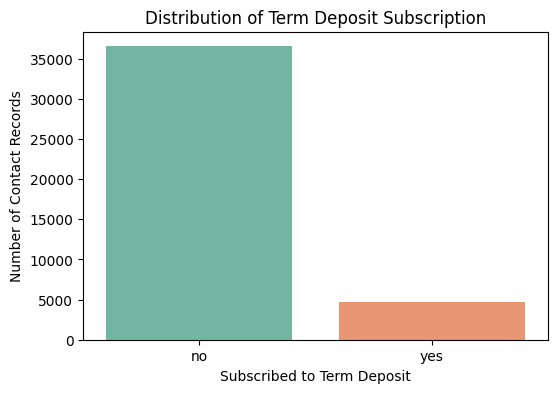

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a figure that is 6 inches wide and 4 inches tall
plt.figure(figsize=(6, 4))

# Create a bar chart showing the number of records for each target class
sns.countplot(
    data=df,              # Use our dataset
    x="y",                # Put the target variable on the x-axis
    hue="y",              # Use target categories to colour the bars
    palette="Set2",       # Choose a colour palette
    legend=False          # No separate legend is needed
)

# Add a descriptive title
plt.title("Distribution of Term Deposit Subscription")

# Label the x-axis
plt.xlabel("Subscribed to Term Deposit")

# Label the y-axis
plt.ylabel("Number of Contact Records")

# Display the completed plot
plt.show()


In [ ]:
# Create an empty dictionary to store unknown-value counts
unknown_counts = {}

# Check every column in the dataset
for column in df.columns:

    # Convert values to lowercase text and check which ones are "unknown"
    # .sum() counts how many True values were found
    unknown_counts[column] = (
        df[column].astype(str).str.lower() == "unknown"
    ).sum()

# Convert the dictionary into a Pandas Series
unknown_counts = pd.Series(unknown_counts)

# Create a table containing the count and percentage of unknown values
unknown_summary = pd.DataFrame({
    "Unknown Count": unknown_counts,

    # Calculate what percentage of the dataset is unknown
    "Unknown Percentage": (
        unknown_counts / len(df) * 100
    ).round(2)
})

# Show only columns that actually contain unknown values
# Sort them from the most unknown values to the least
unknown_summary[
    unknown_summary["Unknown Count"] > 0
].sort_values(
    "Unknown Count",
    ascending=False
)


,Unknown Count,Unknown Percentage
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


In [ ]:
# Show how many times each pdays value appears
# sort_index() displays the values from smallest to largest
print(df["pdays"].value_counts().sort_index())


pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64


In [ ]:
# Examine how often each value of pdays appears
# sort_index() arranges the pdays values from smallest to largest
print(df["pdays"].value_counts().sort_index())


# Count the number of records where pdays is equal to 999
# 999 is a special code in this dataset
pdays_999_count = (df["pdays"] == 999).sum()


# Calculate what percentage of all records have pdays = 999
pdays_999_percentage = (
    pdays_999_count / len(df) * 100
)


# Display the number of records with pdays = 999
print(
    "Number of contact records with pdays = 999:",
    pdays_999_count
)


# Display the percentage of records with pdays = 999
# round(..., 2) keeps the result to 2 decimal places
print(
    "Percentage of contact records with pdays = 999:",
    round(pdays_999_percentage, 2),
    "%"
)


# Create a temporary binary indicator:
# 1 = pdays is 999
# 0 = pdays is not 999
pdays_999 = (df["pdays"] == 999).astype(int)


# Count how many records have pdays = 999 and how many do not
print(
    pdays_999.value_counts()
)


pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64
Number of contact records with pdays = 999: 39673
Percentage of contact records with pdays = 999: 96.32 %
pdays
1    39673
0     1515
Name: count, dtype: int64


In [ ]:
# Descriptive statistics for numerical variables
# Shows count, mean, standard deviation, quartiles and range
# Transpose makes each numerical variable appear as a row
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [ ]:
# Display the categories and their frequencies for each categorical variable

for column in categorical_cols:

    # Print a separator to make the output easier to read
    print("\n" + "=" * 60)

    # Display the name of the current column
    print(column)

    # Print another separator
    print("=" * 60)

    # Count each category
    # dropna=False also shows NaN values if they exist
    print(df[column].value_counts(dropna=False))



job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

job
student          31.43
retired          25.23
unemployed       14.20
admin.           12.97
management       11.22
unknown          11.21
technician       10.83
self-employed    10.49
housemaid        10.00
entrepreneur      8.52
services          8.14
blue-collar       6.89
Name: y, dtype: float64


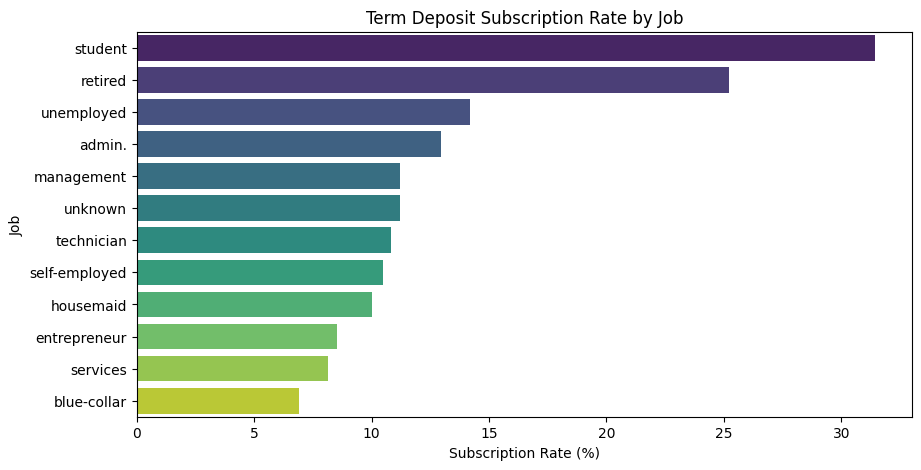

In [ ]:
# Calculate subscription rate by job

job_subscription = (
    df.groupby("job")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(job_subscription.round(2))

plt.figure(figsize=(10, 5))

sns.barplot(
    x=job_subscription.values,
    y=job_subscription.index,
    hue=job_subscription.index,
    palette="viridis",
    legend=False
)

plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.title("Term Deposit Subscription Rate by Job")

plt.show()



contact
cellular     14.74
telephone     5.23
Name: y, dtype: float64


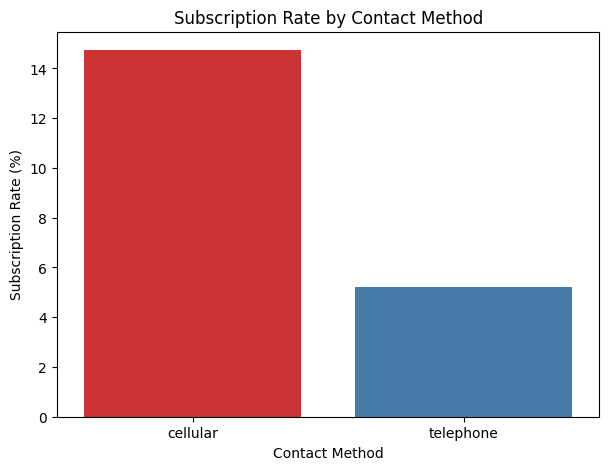

In [ ]:
# Subscription rate by contact method

contact_subscription = (
    df.groupby("contact")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(contact_subscription.round(2))

plt.figure(figsize=(7, 5))

sns.barplot(
    x=contact_subscription.index,
    y=contact_subscription.values,
    hue=contact_subscription.index,
    palette="Set1",
    legend=False
)

plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Contact Method")

plt.show()


In [ ]:
# Relationship: Previous campaign outcome (poutcome) vs subscription (y)

# Group customers according to their previous campaign outcome,
# then calculate the proportion of "yes" and "no" subscriptions
# within each poutcome group.
poutcome_subscription = (
    df.groupby("poutcome")["y"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

# Select the "yes" subscription column and convert the proportions
# into percentages by multiplying them by 100.
poutcome_subscription["yes"] = (
    poutcome_subscription["yes"] * 100
)

# Display the subscription rate for each previous campaign outcome.
poutcome_subscription[["yes"]]

y,yes
poutcome,
failure,14.228598
nonexistent,8.832213
success,65.112891


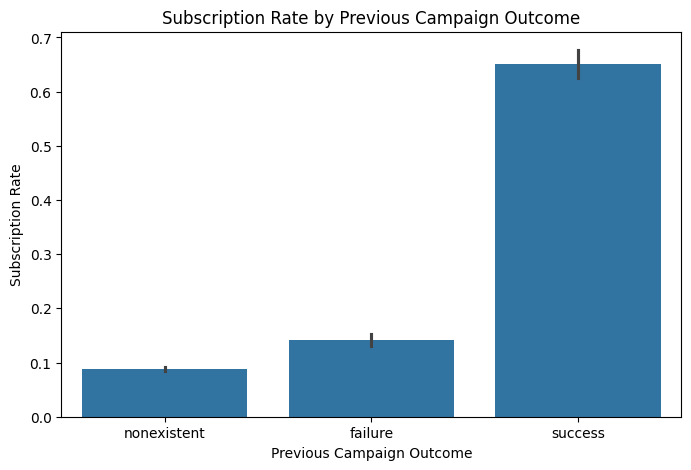

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="poutcome",
    y=df["y"].eq("yes").astype(int)
)

plt.ylabel("Subscription Rate")
plt.xlabel("Previous Campaign Outcome")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.show()


In [ ]:
# Relationship: Number of campaign contacts (campaign) vs subscription (y)

# Define groups for the number of contacts made during the campaign.
# Grouping the values makes the relationship easier to interpret
# than plotting every individual campaign value.
campaign_bins = [0, 1, 2, 3, 5, 10, float("inf")]

# Define readable labels for the contact groups.
campaign_labels = [
    "1",
    "2",
    "3",
    "4–5",
    "6–10",
    "11+"
]

# Create a temporary column that assigns each customer
# to one of the campaign contact groups.
df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=campaign_bins,
    labels=campaign_labels
)

# Calculate the subscription rate within each campaign group.
# (y == "yes") identifies customers who subscribed.
# The mean of these True/False values gives the proportion
# of customers who subscribed, which is then multiplied by 100
# to express the result as a percentage.
campaign_subscription = (
    df.groupby("campaign_group", observed=False)["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .reset_index(name="subscription_rate")
)

# Display the subscription rate for each campaign contact group.
campaign_subscription

,campaign_group,subscription_rate
0,1,13.037071
1,2,11.456954
2,3,10.747051
3,4–5,8.682353
4,6–10,6.319555
5,11+,3.107020


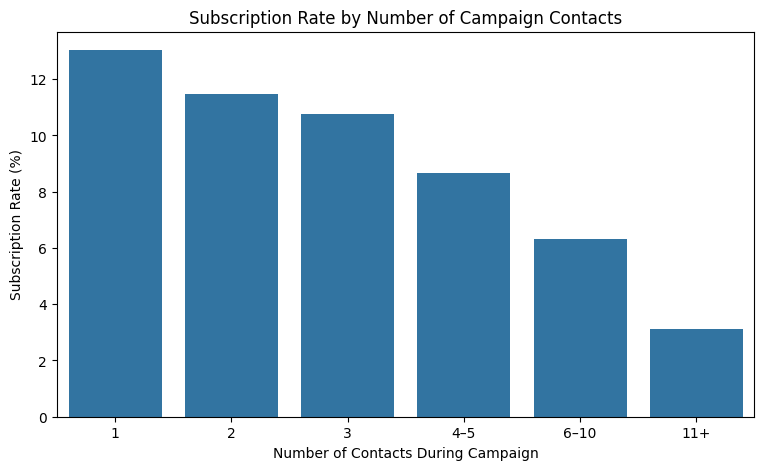

In [ ]:
# Plot the subscription rate for each campaign contact group.

plt.figure(figsize=(9, 5))

# Create a bar chart showing the subscription rate
# for each number-of-contact group.
sns.barplot(
    data=campaign_subscription,
    x="campaign_group",
    y="subscription_rate"
)

# Label the x-axis to explain what the groups represent.
plt.xlabel("Number of Contacts During Campaign")

# Label the y-axis to show that the values are percentages.
plt.ylabel("Subscription Rate (%)")

# Add a descriptive title to the chart.
plt.title("Subscription Rate by Number of Campaign Contacts")

# Display the chart.
plt.show()

In [ ]:
# Define groups for the number of days since the client was previously contacted.
# The value 999 is treated separately because it represents clients
# who were not previously contacted in the relevant campaign history.

pdays_bins = [-1, 7, 30, 90, float("inf")]

# Define readable labels for the pdays groups.
pdays_labels = [
    "0–7",
    "8–30",
    "31–90",
    "91+"
]

# Create a temporary column that groups pdays values.
# Values equal to 999 will be handled separately below.
df["pdays_group"] = pd.cut(
    df["pdays"].where(df["pdays"] != 999),
    bins=pdays_bins,
    labels=pdays_labels
)

In [ ]:
# Convert the categorical column to an ordinary object column.
# This allows us to add our special 999 category.
df["pdays_group"] = df["pdays_group"].astype(object)

# Assign a separate label to customers with pdays = 999.
df.loc[
    df["pdays"] == 999,
    "pdays_group"
] = "999 (not previously contacted)"

df[["pdays", "pdays_group"]].head(10)

,pdays,pdays_group
0,999,999 (not previously contacted)
1,999,999 (not previously contacted)
2,999,999 (not previously contacted)
3,999,999 (not previously contacted)
4,999,999 (not previously contacted)
5,999,999 (not previously contacted)
6,999,999 (not previously contacted)
7,999,999 (not previously contacted)
8,999,999 (not previously contacted)
9,999,999 (not previously contacted)


In [ ]:
# Calculate the subscription rate within each pdays group.
# (y == "yes") identifies customers who subscribed.
# The mean of these True/False values gives the proportion
# of customers who subscribed, which is then multiplied by 100
# to express the result as a percentage.

pdays_subscription = (
    df.groupby("pdays_group", observed=False)["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .reset_index(name="subscription_rate")
)

# Display the subscription rate for each pdays group.
pdays_subscription

,pdays_group,subscription_rate
0,0–7,65.760408
1,8–30,57.100592
2,999 (not previously contacted),9.258186


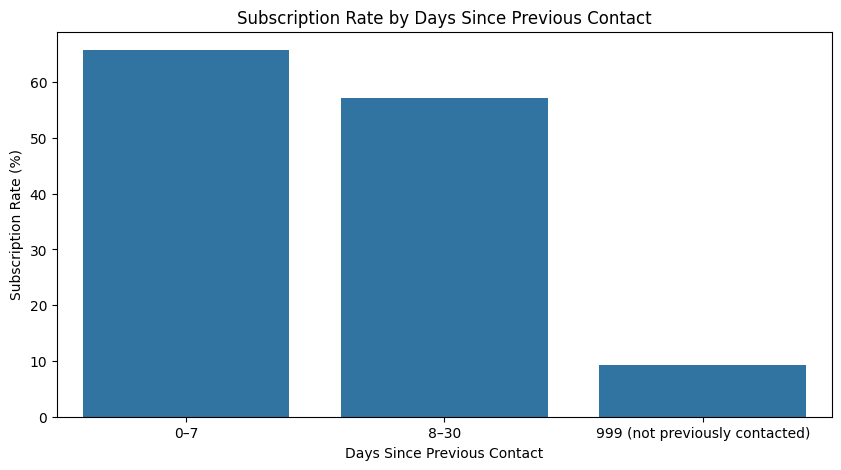

In [ ]:
# Plot the subscription rate for each pdays group.

plt.figure(figsize=(10, 5))

# Create a bar chart using the pdays groups on the x-axis
# and their subscription rates on the y-axis.
sns.barplot(
    data=pdays_subscription,
    x="pdays_group",
    y="subscription_rate"
)

# Label the x-axis.
plt.xlabel("Days Since Previous Contact")

# Label the y-axis.
plt.ylabel("Subscription Rate (%)")

# Add a descriptive title.
plt.title("Subscription Rate by Days Since Previous Contact")

# Display the chart.
plt.show()

## Feature availability and decision-point assessment

The modelling decision is made **before the current phone call starts**. The UCI documentation defines `duration` as the duration of the last contact and `campaign` as the number of contacts performed during the current campaign, **including the last contact**. Because the recorded `campaign` value includes the current contact, its raw value is not safely available before that contact begins, so it is excluded from the predictive feature set.

| Input column | Available before call? | Modelling decision | Reason |
|---|---:|---:|---|
| `age`, `job`, `marital`, `education` | Yes | Include | Client attributes available before contact. |
| `default`, `housing`, `loan` | Yes | Include | Existing credit/loan information. |
| `contact`, `month`, `day_of_week` | Yes, under campaign-planning assumption | Include | These are treated as planned contact settings known before the call. |
| `duration` | No | Exclude | It is the duration of the contact and is only known during/after the call. |
| `campaign` | No, as recorded | Exclude | UCI defines it as contacts during the current campaign including the last contact, so the recorded value contains information about the current contact. |
| `pdays`, `previous`, `poutcome` | Yes | Include | Previous-campaign history is available before a new contact. |
| `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | Yes, as campaign-period indicators | Include | Macroeconomic indicators associated with the campaign period. |

This is a predictive analysis: the historical data can identify records associated with subscription, but it does not establish that contacting a client causes the subscription.

**Dataset source:** UCI Machine Learning Repository, Bank Marketing. The UCI page states that `bank-additional-full.csv` contains 41,188 examples, 20 inputs, is ordered by date, and defines the relevant campaign/history variables.


In [ ]:
# Define the original input features that are available before the call.
# `duration` is excluded because it is post-contact.
# `campaign` is excluded because the UCI definition includes the current contact.
feature_columns = [
    "age", "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "pdays", "previous", "poutcome",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m",
    "nr.employed"
]

X = df[feature_columns].copy()
y = df["y"].copy()

print("Number of modelling features:", X.shape[1])
print("\nModelling features:")
print(X.columns.tolist())


Number of modelling features: 18

Modelling features:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [ ]:
# Automatically identify numerical features in X
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Automatically identify categorical features in X
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Display the feature groups
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("Total number of Numerical Features : ",len(numeric_features))
print("Total number of Categorical Features : ",len(categorical_features))


Numerical features:
['age', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Total number of Numerical Features :  8
Total number of Categorical Features :  10


## Handling of `unknown` Values

The dataset contains the value `unknown` in some categorical variables. These values are treated as an explicit category rather than being automatically converted into missing values.

Keeping `unknown` as a separate category preserves the information that the value was not available or was recorded as unknown in the original dataset.

Therefore, the preprocessing pipeline will not replace `unknown` with the most frequent category. Instead, `unknown` will remain as a categorical level and will be handled by one-hot encoding.

Actual missing values (`NaN`), if present, will be handled separately by the preprocessing pipeline:
- numerical variables: median imputation
- categorical variables: most-frequent imputation

In [ ]:
# Import tools for numerical preprocessing
# Import the standard Pipeline class
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Create a preprocessing pipeline for numerical features
numeric_transformer = Pipeline(
    steps=[
        (
            # Fill missing numerical values with the median
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            # Scale numerical features to a similar range
            "scaler",
            StandardScaler()
        )
    ]
)

# Create a preprocessing pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
        (
            # Fill missing categorical values with the most common category
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            # Convert categories into numerical 0/1 columns
            # Ignore categories that appear only in new data
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)


In [ ]:
# Import ColumnTransformer
from sklearn.compose import ColumnTransformer

# Apply the appropriate preprocessing to each type of feature
preprocessor = ColumnTransformer(
    transformers=[
        (
            # Numerical preprocessing
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            # Categorical preprocessing
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


In [ ]:

preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)

print(preprocessing_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                  

In [ ]:
# ============================================================
# Chronological Development / Validation / Final Holdout Split
# ============================================================

# Step 1: Reserve the latest 20% as the final holdout
holdout_size = int(len(X) * 0.20)

X_train = X.iloc[:-holdout_size].copy()
X_holdout = X.iloc[-holdout_size:].copy()

y_train = y.iloc[:-holdout_size].copy()
y_holdout = y.iloc[-holdout_size:].copy()

# Step 2: Split the earlier 80% chronologically into
# Development (80%) and Validation (20%)
development_size = int(len(X_train) * 0.80)

X_development = X_train.iloc[:development_size].copy()
X_validation = X_train.iloc[development_size:].copy()

y_development = y_train.iloc[:development_size].copy()
y_validation = y_train.iloc[development_size:].copy()

print("Development set:", X_development.shape)
print("Validation set:", X_validation.shape)
print("Final holdout:", X_holdout.shape)

Development set: (26360, 18)
Validation set: (6591, 18)
Final holdout: (8237, 18)


In [ ]:
# Fit preprocessing only on Development data
X_development_transformed = preprocessor.fit_transform(X_development)

# Apply the already-fitted preprocessing to Validation
X_validation_transformed = preprocessor.transform(X_validation)

# Apply the already-fitted preprocessing to Final Holdout
X_holdout_transformed = preprocessor.transform(X_holdout)

print("Development transformed shape:", X_development_transformed.shape)
print("Validation transformed shape:", X_validation_transformed.shape)
print("Holdout transformed shape:", X_holdout_transformed.shape)

Development transformed shape: (26360, 57)
Validation transformed shape: (6591, 57)
Holdout transformed shape: (8237, 57)


In [ ]:
print("Total rows:", len(X))
print("Development:", len(X_development))
print("Validation:", len(X_validation))
print("Holdout:", len(X_holdout))

print("Sum of splits:",
      len(X_development) + len(X_validation) + len(X_holdout))

Total rows: 41188
Development: 26360
Validation: 6591
Holdout: 8237
Sum of splits: 41188


In [ ]:
# Check that the preprocessing produced the expected number of features.
print("\nOriginal training features:", X_train.shape[1])
print("Transformed training features:", X_train_transformed.shape[1])

# Check that the training and holdout data have the same transformed structure.
print("Transformed training rows:", X_train_transformed.shape[0])
print("Transformed holdout rows:", X_holdout_transformed.shape[0])


Original training features: 18
Transformed training features: 60
Transformed training rows: 32950
Transformed holdout rows: 8237


In [ ]:
# Convert the target variable from "no"/"yes" to 0/1.
# 1 = client subscribed
# 0 = client did not subscribe

y_train_binary = (y_train == "yes").astype(int)
y_holdout_binary = (y_holdout == "yes").astype(int)

print("Training target distribution:")
print(y_train_binary.value_counts())

print("\nHoldout target distribution:")
print(y_holdout_binary.value_counts())

Training target distribution:
y
0    30851
1     2100
Name: count, dtype: int64

Holdout target distribution:
y
0    5697
1    2540
Name: count, dtype: int64


In [ ]:
# Import DummyClassifier to create a simple baseline model.
from sklearn.dummy import DummyClassifier


# Create a majority-class baseline.
# "most_frequent" means the model always predicts
# whichever target class is most common in the training data.
majority_baseline = DummyClassifier(
    strategy="most_frequent"
)


# Fit the baseline using the training data only.
# The model uses y_train_binary to determine
# which class is the majority class.
majority_baseline.fit(
    X_train,
    y_train_binary
)


# Generate class predictions for the final holdout data.
# Because this is a majority-class baseline,
# the same class will be predicted for every holdout observation.
majority_predictions = majority_baseline.predict(
    X_holdout
)


# Generate predicted probabilities for the final holdout data.
# Each customer receives the same class probabilities
# because the baseline does not use customer-specific features.
majority_probabilities = majority_baseline.predict_proba(
    X_holdout
)


# Display the first few predictions.
print("First 10 predictions:")
print(majority_predictions[:10])


# Display the first few predicted probabilities.
print("\nFirst 10 predicted probabilities:")
print(majority_probabilities[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


# Calculate the confusion matrix.
# It compares the actual holdout outcomes with
# the predictions made by the majority baseline.
baseline_cm = confusion_matrix(
    y_holdout_binary,
    majority_predictions
)


# Calculate precision.
# This measures how many predicted YES cases
# were actually YES.
baseline_precision = precision_score(
    y_holdout_binary,
    majority_predictions,
    zero_division=0
)


# Calculate recall.
# This measures how many actual YES cases
# were successfully identified.
baseline_recall = recall_score(
    y_holdout_binary,
    majority_predictions,
    zero_division=0
)


# Calculate F1-score.
# F1 combines precision and recall into one measure.
baseline_f1 = f1_score(
    y_holdout_binary,
    majority_predictions,
    zero_division=0
)


# Display the results.
print("Majority Baseline Results")
print("--------------------------")

print("\nConfusion Matrix:")
print(baseline_cm)

print("\nPrecision:", round(baseline_precision, 4))
print("Recall:", round(baseline_recall, 4))
print("F1-score:", round(baseline_f1, 4))

Majority Baseline Results
--------------------------

Confusion Matrix:
[[5697    0]
 [2540    0]]

Precision: 0.0
Recall: 0.0
F1-score: 0.0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)
logistic_model.fit(
    X_train,
    y_train_binary
)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [ ]:
logistic_predictions = logistic_model.predict(
    X_holdout
)

logistic_probabilities = logistic_model.predict_proba(
    X_holdout
)[:, 1]

print("First 10 predicted classes:")
print(logistic_predictions[:10])

print("\nFirst 10 predicted probabilities:")
print(logistic_probabilities[:10])

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.04912256 0.03669471 0.07502354 0.035372   0.07215528 0.03433296
 0.0672707  0.08281264 0.07726694 0.0326887 ]


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# --------------------------------------------------
# 1. Confusion Matrix
# --------------------------------------------------

logistic_cm = confusion_matrix(
    y_holdout_binary,
    logistic_predictions
)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)


# --------------------------------------------------
# 2. Classification Metrics
# --------------------------------------------------

logistic_accuracy = accuracy_score(
    y_holdout_binary,
    logistic_predictions
)

logistic_precision = precision_score(
    y_holdout_binary,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_holdout_binary,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_holdout_binary,
    logistic_predictions,
    zero_division=0
)


# --------------------------------------------------
# 3. Probability-based Metrics
# --------------------------------------------------

logistic_roc_auc = roc_auc_score(
    y_holdout_binary,
    logistic_probabilities
)

logistic_average_precision = average_precision_score(
    y_holdout_binary,
    logistic_probabilities
)


# --------------------------------------------------
# 4. Display Results
# --------------------------------------------------

print("\nLogistic Regression Evaluation")
print("--------------------------------")
print(f"Accuracy:            {logistic_accuracy:.4f}")
print(f"Precision:           {logistic_precision:.4f}")
print(f"Recall:              {logistic_recall:.4f}")
print(f"F1-score:            {logistic_f1:.4f}")
print(f"ROC-AUC:             {logistic_roc_auc:.4f}")
print(f"Average Precision:   {logistic_average_precision:.4f}")

Logistic Regression Confusion Matrix:
[[5095  602]
 [1670  870]]

Logistic Regression Evaluation
--------------------------------
Accuracy:            0.7242
Precision:           0.5910
Recall:              0.3425
F1-score:            0.4337
ROC-AUC:             0.7476
Average Precision:   0.5249


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)
random_forest_model.fit(
    X_train,
    y_train_binary
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [ ]:
random_forest_predictions = random_forest_model.predict(
    X_holdout
)

random_forest_probabilities = random_forest_model.predict_proba(
    X_holdout
)[:, 1]

print("First 10 predicted classes:")
print(random_forest_predictions[:10])

print("\nFirst 10 predicted probabilities:")
print(random_forest_probabilities[:10])

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.15341129 0.09335622 0.06630759 0.07072881 0.05655713 0.07750458
 0.12759663 0.09399221 0.093693   0.02443365]


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# --------------------------------------------------
# 1. Confusion Matrix
# --------------------------------------------------

random_forest_cm = confusion_matrix(
    y_holdout_binary,
    random_forest_predictions
)

print("Random Forest Confusion Matrix:")
print(random_forest_cm)


# --------------------------------------------------
# 2. Classification Metrics
# --------------------------------------------------

random_forest_accuracy = accuracy_score(
    y_holdout_binary,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_holdout_binary,
    random_forest_predictions,
    zero_division=0
)

random_forest_recall = recall_score(
    y_holdout_binary,
    random_forest_predictions,
    zero_division=0
)

random_forest_f1 = f1_score(
    y_holdout_binary,
    random_forest_predictions,
    zero_division=0
)


# --------------------------------------------------
# 3. Probability-Based Metrics
# --------------------------------------------------

random_forest_roc_auc = roc_auc_score(
    y_holdout_binary,
    random_forest_probabilities
)

random_forest_average_precision = average_precision_score(
    y_holdout_binary,
    random_forest_probabilities
)


# --------------------------------------------------
# 4. Display Results
# --------------------------------------------------

print("\nRandom Forest Evaluation")
print("--------------------------------")
print(f"Accuracy:            {random_forest_accuracy:.4f}")
print(f"Precision:           {random_forest_precision:.4f}")
print(f"Recall:              {random_forest_recall:.4f}")
print(f"F1-score:            {random_forest_f1:.4f}")
print(f"ROC-AUC:             {random_forest_roc_auc:.4f}")

print(f"Average Precision:   {random_forest_average_precision:.4f}")

Random Forest Confusion Matrix:
[[5697    0]
 [2540    0]]

Random Forest Evaluation
--------------------------------
Accuracy:            0.6916
Precision:           0.0000
Recall:              0.0000
F1-score:            0.0000
ROC-AUC:             0.7394
Average Precision:   0.5335


In [ ]:
boosting_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)
boosting_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", boosting_categorical_transformer, categorical_features)
    ]
)

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

boosting_model = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42
        ))
    ]
)

boosting_model.fit(
    X_train,
    y_train_binary
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'pdays', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier',
                 HistGradientBoostingClassifier(l2_regularization=1.0,
                                                learning_rate=0.05,
                                                max_iter=200, max_leaf_nodes=15,
                                                random_state=42))])

In [ ]:
boosting_predictions = boosting_model.predict(X_holdout)

boosting_probabilities = boosting_model.predict_proba(X_holdout)[:, 1]

print("First 10 predicted classes:")
print(boosting_predictions[:10])

print("\nFirst 10 predicted probabilities:")
print(boosting_probabilities[:10])

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.12596197 0.03768609 0.08766247 0.05055055 0.04815242 0.03589904
 0.07832979 0.07538194 0.07587846 0.0248641 ]


In [ ]:
boosting_confusion_matrix = confusion_matrix(
    y_holdout_binary,
    boosting_predictions
)

boosting_accuracy = accuracy_score(
    y_holdout_binary,
    boosting_predictions
)

boosting_precision = precision_score(
    y_holdout_binary,
    boosting_predictions,
    zero_division=0
)

boosting_recall = recall_score(
    y_holdout_binary,
    boosting_predictions,
    zero_division=0
)

boosting_f1 = f1_score(
    y_holdout_binary,
    boosting_predictions,
    zero_division=0
)

boosting_roc_auc = roc_auc_score(
    y_holdout_binary,
    boosting_probabilities
)

boosting_average_precision = average_precision_score(
    y_holdout_binary,
    boosting_probabilities
)

print("Boosting Confusion Matrix:")
print(boosting_confusion_matrix)

print("\nBoosting Metrics:")
print(f"Accuracy:           {boosting_accuracy:.4f}")
print(f"Precision:          {boosting_precision:.4f}")
print(f"Recall:             {boosting_recall:.4f}")
print(f"F1 Score:           {boosting_f1:.4f}")
print(f"ROC-AUC:            {boosting_roc_auc:.4f}")
print(f"Average Precision:  {boosting_average_precision:.4f}")

Boosting Confusion Matrix:
[[5597  100]
 [2450   90]]

Boosting Metrics:
Accuracy:           0.6904
Precision:          0.4737
Recall:             0.0354
F1 Score:           0.0659
ROC-AUC:            0.6200
Average Precision:  0.4128


In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_development_transformed, y_development)

qda_validation_proba = qda.predict_proba(X_validation_transformed)[:, 1]

print("QDA validation predictions generated successfully.")

QDA validation predictions generated successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [ ]:
def precision_at_k(y_true, scores, k=500):
    ranking = np.argsort(scores)[::-1][:k]
    return np.mean(np.asarray(y_true)[ranking] == "yes")


def lift_at_k(y_true, scores, k=500):
    precision = precision_at_k(y_true, scores, k)
    base_rate = np.mean(np.asarray(y_true) == "yes")
    return precision / base_rate


qda_precision_500 = precision_at_k(
    y_validation,
    qda_validation_proba,
    k=500
)

qda_lift_500 = lift_at_k(
    y_validation,
    qda_validation_proba,
    k=500
)

print("QDA Precision@500:", round(qda_precision_500, 3))
print("QDA Lift@500:", round(qda_lift_500, 3))

QDA Precision@500: 0.062
QDA Lift@500: 0.488


In [ ]:
qda_results = []

for reg in [0.0, 0.1, 0.3, 0.5, 0.7]:

    qda_model = QuadraticDiscriminantAnalysis(
        reg_param=reg
    )

    qda_model.fit(
        X_development_transformed,
        y_development
    )

    validation_scores = qda_model.predict_proba(
        X_validation_transformed
    )[:, 1]

    precision = precision_at_k(
        y_validation,
        validation_scores,
        k=500
    )

    lift = lift_at_k(
        y_validation,
        validation_scores,
        k=500
    )

    qda_results.append({
        "reg_param": reg,
        "precision_at_500": precision,
        "lift_at_500": lift
    })

qda_results_df = pd.DataFrame(qda_results)

qda_results_df

/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


,reg_param,precision_at_500,lift_at_500
0,0.0,0.062,0.487640
1,0.1,0.098,0.770785
2,0.3,0.210,1.651683
3,0.5,0.342,2.689883
4,0.7,0.284,2.233704


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda.fit(
    X_development_transformed,
    y_development
)

lda_validation_proba = lda.predict_proba(
    X_validation_transformed
)[:, 1]

print("LDA validation predictions generated successfully.")

LDA validation predictions generated successfully.


In [ ]:
lda_precision_500 = precision_at_k(
    y_validation,
    lda_validation_proba,
    k=500
)

lda_lift_500 = lift_at_k(
    y_validation,
    lda_validation_proba,
    k=500
)

print("LDA Precision@500:", round(lda_precision_500, 3))
print("LDA Lift@500:", round(lda_lift_500, 3))

LDA Precision@500: 0.058
LDA Lift@500: 0.456


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_weighted_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_weighted_model.fit(
    X_train,
    y_train_binary
)

print("Class-weighted Logistic Regression fitted successfully.")

Class-weighted Logistic Regression fitted successfully.


In [ ]:
weighted_logistic_predictions = logistic_weighted_model.predict(X_holdout)

weighted_logistic_probabilities = (
    logistic_weighted_model.predict_proba(X_holdout)[:, 1]
)

print("First 10 class-weighted Logistic Regression predictions:")
print(weighted_logistic_predictions[:10])

print("\nFirst 10 positive-class probabilities:")
print(weighted_logistic_probabilities[:10])

First 10 class-weighted Logistic Regression predictions:
[0 0 1 0 1 0 1 1 1 0]

First 10 positive-class probabilities:
[0.41642403 0.36815998 0.54321368 0.35266806 0.54395534 0.36043482
 0.52530192 0.55450663 0.55185574 0.32746129]


In [ ]:
weighted_logistic_confusion_matrix = confusion_matrix(
    y_holdout_binary,
    weighted_logistic_predictions
)

weighted_logistic_accuracy = accuracy_score(
    y_holdout_binary,
    weighted_logistic_predictions
)

weighted_logistic_precision = precision_score(
    y_holdout_binary,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_recall = recall_score(
    y_holdout_binary,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_f1 = f1_score(
    y_holdout_binary,
    weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_roc_auc = roc_auc_score(
    y_holdout_binary,
    weighted_logistic_probabilities
)

weighted_logistic_average_precision = average_precision_score(
    y_holdout_binary,
    weighted_logistic_probabilities
)

print("Class-Weighted Logistic Regression Confusion Matrix:")
print(weighted_logistic_confusion_matrix)

print("\nClass-Weighted Logistic Regression Metrics:")
print(f"Accuracy:           {weighted_logistic_accuracy:.4f}")
print(f"Precision:          {weighted_logistic_precision:.4f}")
print(f"Recall:             {weighted_logistic_recall:.4f}")
print(f"F1 Score:           {weighted_logistic_f1:.4f}")
print(f"ROC-AUC:            {weighted_logistic_roc_auc:.4f}")
print(f"Average Precision:  {weighted_logistic_average_precision:.4f}")

Class-Weighted Logistic Regression Confusion Matrix:
[[1697 4000]
 [ 323 2217]]

Class-Weighted Logistic Regression Metrics:
Accuracy:           0.4752
Precision:          0.3566
Recall:             0.8728
F1 Score:           0.5063
ROC-AUC:            0.7057
Average Precision:  0.5072


In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Helper function to calculate all metrics
def calculate_metrics(y_true, predictions, probabilities):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "Average_Precision": average_precision_score(y_true, probabilities)
    }


# Calculate metrics for each model
majority_metrics = calculate_metrics(
    y_holdout_binary,
    majority_predictions,
    majority_probabilities[:, 1]
)

logistic_metrics = calculate_metrics(
    y_holdout_binary,
    logistic_predictions,
    logistic_probabilities
)

random_forest_metrics = calculate_metrics(
    y_holdout_binary,
    random_forest_predictions,
    random_forest_probabilities
)

boosting_metrics = calculate_metrics(
    y_holdout_binary,
    boosting_predictions,
    boosting_probabilities
)

lda_metrics = calculate_metrics(
    y_holdout_binary,
    lda_predictions,
    lda_probabilities
)

qda_metrics = calculate_metrics(
    y_holdout_binary,
    qda_predictions,
    qda_probabilities
)

weighted_logistic_metrics = calculate_metrics(
    y_holdout_binary,
    weighted_logistic_predictions,
    weighted_logistic_probabilities
)


# Create comparison table
model_comparison_initial = pd.DataFrame([
    {"Model": "Majority Baseline", **majority_metrics},
    {"Model": "Logistic Regression", **logistic_metrics},
    {"Model": "Random Forest", **random_forest_metrics},
    {"Model": "HistGradientBoosting", **boosting_metrics},
    {"Model": "LDA", **lda_metrics},
    {"Model": "QDA", **qda_metrics},
    {"Model": "Logistic Regression (Class Weighted)", **weighted_logistic_metrics}
])

model_comparison_initial.round(4)


ValueError: Found input variables with inconsistent numbers of samples: [8237, 8238]

In [ ]:
# Create a time-ordered validation split inside the original training period

train_split_index = int(len(X_train) * 0.80)

X_train_dev = X_train.iloc[:train_split_index].copy()
X_validation = X_train.iloc[train_split_index:].copy()

y_train_dev = y_train.iloc[:train_split_index].copy()
y_validation = y_train.iloc[train_split_index:].copy()

# Convert target to binary
y_train_dev_binary = (y_train_dev == "yes").astype(int)
y_validation_binary = (y_validation == "yes").astype(int)

print("Development training period:", X_train_dev.shape)
print("Validation period:", X_validation.shape)
print("Final holdout:", X_holdout.shape)

print("\nDevelopment training dates/order:")
print(X_train_dev.index.min(), "to", X_train_dev.index.max())

print("\nValidation dates/order:")
print(X_validation.index.min(), "to", X_validation.index.max())

print("\nFinal holdout dates/order:")
print(X_holdout.index.min(), "to", X_holdout.index.max())

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# 1. Create the majority-class baseline
validation_majority_model = DummyClassifier(
    strategy="most_frequent"
)

# 2. Train ONLY on the development period
validation_majority_model.fit(
    X_train_dev,
    y_train_dev_binary
)

# 3. Predict on the validation period
validation_majority_predictions = validation_majority_model.predict(
    X_validation
)

validation_majority_probabilities = (
    validation_majority_model.predict_proba(X_validation)[:, 1]
)

# 4. Calculate validation metrics
validation_majority_metrics = {
    "Accuracy": accuracy_score(
        y_validation_binary,
        validation_majority_predictions
    ),
    "Precision": precision_score(
        y_validation_binary,
        validation_majority_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation_binary,
        validation_majority_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation_binary,
        validation_majority_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation_binary,
        validation_majority_probabilities
    ),
    "Average_Precision": average_precision_score(
        y_validation_binary,
        validation_majority_probabilities
    )
}

# 5. Display results
pd.DataFrame(
    [validation_majority_metrics],
    index=["Validation Majority Baseline"]
).round(4)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create Logistic Regression pipeline
validation_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

# Train only on the development period
validation_logistic_model.fit(
    X_train_dev,
    y_train_dev_binary
)

# Predict validation classes
validation_logistic_predictions = (
    validation_logistic_model.predict(X_validation)
)

# Predict probability of "yes"
validation_logistic_probabilities = (
    validation_logistic_model.predict_proba(X_validation)[:, 1]
)

# Calculate validation metrics
validation_logistic_metrics = {
    "Accuracy": accuracy_score(
        y_validation_binary,
        validation_logistic_predictions
    ),
    "Precision": precision_score(
        y_validation_binary,
        validation_logistic_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation_binary,
        validation_logistic_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation_binary,
        validation_logistic_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation_binary,
        validation_logistic_probabilities
    ),
    "Average_Precision": average_precision_score(
        y_validation_binary,
        validation_logistic_probabilities
    )
}

# Display results
pd.DataFrame(
    [validation_logistic_metrics],
    index=["Validation Logistic Regression"]
).round(4)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Random Forest validation pipeline
validation_random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train ONLY on development data
validation_random_forest_model.fit(
    X_train_dev,
    y_train_dev_binary
)

# Predict validation classes
validation_random_forest_predictions = (
    validation_random_forest_model.predict(X_validation)
)

# Predict probability of "yes"
validation_random_forest_probabilities = (
    validation_random_forest_model.predict_proba(X_validation)[:, 1]
)

# Calculate metrics
validation_random_forest_metrics = {
    "Accuracy": accuracy_score(
        y_validation_binary,
        validation_random_forest_predictions,
    ),
    "Precision": precision_score(
        y_validation_binary,
        validation_random_forest_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation_binary,
        validation_random_forest_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation_binary,
        validation_random_forest_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation_binary,
        validation_random_forest_probabilities
    ),
    "Average_Precision": average_precision_score(
        y_validation_binary,
        validation_random_forest_probabilities
    )
}

# Display results
pd.DataFrame(
    [validation_random_forest_metrics],
    index=["Validation Random Forest"]
).round(4)

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

# Boosting validation pipeline
validation_boosting_model = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42
        ))
    ]
)

# Train ONLY on development data
validation_boosting_model.fit(
    X_train_dev,
    y_train_dev_binary
)

# Predict validation classes
validation_boosting_predictions = (
    validation_boosting_model.predict(X_validation)
)

# Predict probability of "yes"
validation_boosting_probabilities = (
    validation_boosting_model.predict_proba(X_validation)[:, 1]
)

# Calculate metrics
validation_boosting_metrics = {
    "Accuracy": accuracy_score(
        y_validation_binary,
        validation_boosting_predictions,
        ),
    "Precision": precision_score(
        y_validation_binary,
        validation_boosting_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation_binary,
        validation_boosting_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation_binary,
        validation_boosting_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation_binary,
        validation_boosting_probabilities
    ),
    "Average_Precision": average_precision_score(
        y_validation_binary,
        validation_boosting_probabilities
    )
}

# Display results
pd.DataFrame(
    [validation_boosting_metrics],
    index=["Validation HistGradientBoosting"]
).round(4)

In [ ]:
# Fit preprocessing ONLY on the development period
lda_qda_preprocessing = preprocessing_pipeline.fit(
    X_train_dev
)

# Transform development and validation data
X_train_dev_transformed = lda_qda_preprocessing.transform(
    X_train_dev
)

X_validation_transformed = lda_qda_preprocessing.transform(
    X_validation
)

print("Development transformed shape:",
      X_train_dev_transformed.shape)

print("Validation transformed shape:",
      X_validation_transformed.shape)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Create the LDA model
validation_lda_model = LinearDiscriminantAnalysis()

# Fit LDA only on the development data
validation_lda_model.fit(
    X_train_dev_transformed,
    y_train_dev_binary
)

# Predict on the validation period
validation_lda_predictions = validation_lda_model.predict(
    X_validation_transformed
)

# Predict probabilities for the positive class ("yes")
validation_lda_probabilities = validation_lda_model.predict_proba(
    X_validation_transformed
)[:, 1]

print("LDA validation predictions completed.")

In [ ]:
# Calculate LDA validation metrics

lda_validation_cm = confusion_matrix(
    y_validation_binary,
    validation_lda_predictions
)

lda_validation_accuracy = accuracy_score(
    y_validation_binary,
    validation_lda_predictions
)

lda_validation_precision = precision_score(
    y_validation_binary,
    validation_lda_predictions,
    zero_division=0
)

lda_validation_recall = recall_score(
    y_validation_binary,
    validation_lda_predictions,
    zero_division=0
)

lda_validation_f1 = f1_score(
    y_validation_binary,
    validation_lda_predictions,
    zero_division=0
)

lda_validation_roc_auc = roc_auc_score(
    y_validation_binary,
    validation_lda_probabilities
)

lda_validation_average_precision = average_precision_score(
    y_validation_binary,
    validation_lda_probabilities
)

print("LDA Validation Confusion Matrix:")
print(lda_validation_cm)

print("\nLDA Validation Metrics:")
print(f"Accuracy:           {lda_validation_accuracy:.4f}")
print(f"Precision:          {lda_validation_precision:.4f}")
print(f"Recall:             {lda_validation_recall:.4f}")
print(f"F1 Score:           {lda_validation_f1:.4f}")
print(f"ROC-AUC:            {lda_validation_roc_auc:.4f}")
print(f"Average Precision:  {lda_validation_average_precision:.4f}")

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Create the QDA model
validation_qda_model = QuadraticDiscriminantAnalysis()

# Fit QDA only on the development data
validation_qda_model.fit(
    X_train_dev_transformed,
    y_train_dev_binary
)

# Predict on the validation period
validation_qda_predictions = validation_qda_model.predict(
    X_validation_transformed
)

# Predict probabilities for the positive class ("yes")
validation_qda_probabilities = validation_qda_model.predict_proba(
    X_validation_transformed
)[:, 1]

print("QDA validation predictions completed.")

In [ ]:
# Calculate QDA validation metrics

qda_validation_cm = confusion_matrix(
    y_validation_binary,
    validation_qda_predictions
)

qda_validation_accuracy = accuracy_score(
    y_validation_binary,
    validation_qda_predictions
)

qda_validation_precision = precision_score(
    y_validation_binary,
    validation_qda_predictions,
    zero_division=0
)

qda_validation_recall = recall_score(
    y_validation_binary,
    validation_qda_predictions,
    zero_division=0
)

qda_validation_f1 = f1_score(
    y_validation_binary,
    validation_qda_predictions,
    zero_division=0
)

qda_validation_roc_auc = roc_auc_score(
    y_validation_binary,
    validation_qda_probabilities
)

qda_validation_average_precision = average_precision_score(
    y_validation_binary,
    validation_qda_probabilities
)

print("QDA Validation Confusion Matrix:")
print(qda_validation_cm)

print("\nQDA Validation Metrics:")
print(f"Accuracy:           {qda_validation_accuracy:.4f}")
print(f"Precision:          {qda_validation_precision:.4f}")
print(f"Recall:             {qda_validation_recall:.4f}")
print(f"F1 Score:           {qda_validation_f1:.4f}")
print(f"ROC-AUC:            {qda_validation_roc_auc:.4f}")
print(f"Average Precision:  {qda_validation_average_precision:.4f}")


In [ ]:
# Class-weighted Logistic Regression
# The model gives more importance to the minority "yes" class.

validation_weighted_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Fit ONLY on the development period
validation_weighted_logistic_model.fit(
    X_train_dev,
    y_train_dev_binary
)

# Predictions on the validation period
validation_weighted_logistic_predictions = (
    validation_weighted_logistic_model.predict(X_validation)
)

# Probability of "yes"
validation_weighted_logistic_probabilities = (
    validation_weighted_logistic_model.predict_proba(X_validation)[:, 1]
)

print("Class-weighted Logistic Regression validation predictions completed.")

In [ ]:
# Calculate class-weighted Logistic Regression validation metrics

weighted_logistic_validation_cm = confusion_matrix(
    y_validation_binary,
    validation_weighted_logistic_predictions
)

weighted_logistic_validation_accuracy = accuracy_score(
    y_validation_binary,
    validation_weighted_logistic_predictions
)

weighted_logistic_validation_precision = precision_score(
    y_validation_binary,
    validation_weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_validation_recall = recall_score(
    y_validation_binary,
    validation_weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_validation_f1 = f1_score(
    y_validation_binary,
    validation_weighted_logistic_predictions,
    zero_division=0
)

weighted_logistic_validation_roc_auc = roc_auc_score(
    y_validation_binary,
    validation_weighted_logistic_probabilities
)

weighted_logistic_validation_average_precision = average_precision_score(
    y_validation_binary,
    validation_weighted_logistic_probabilities
)

print("Class-Weighted Logistic Regression Validation Confusion Matrix:")
print(weighted_logistic_validation_cm)

print("\nClass-Weighted Logistic Regression Validation Metrics:")
print(f"Accuracy:           {weighted_logistic_validation_accuracy:.4f}")
print(f"Precision:          {weighted_logistic_validation_precision:.4f}")
print(f"Recall:             {weighted_logistic_validation_recall:.4f}")
print(f"F1 Score:           {weighted_logistic_validation_f1:.4f}")
print(f"ROC-AUC:            {weighted_logistic_validation_roc_auc:.4f}")
print(f"Average Precision:  {weighted_logistic_validation_average_precision:.4f}")

In [ ]:
# Campaign ranking evaluation on the validation period

import pandas as pd

# Actual positive rate in the validation period
validation_base_rate = y_validation_binary.mean()

# Store model probability predictions
validation_model_scores = {
    "Logistic Regression": validation_logistic_probabilities,
    "Random Forest": validation_random_forest_model.predict_proba(X_validation)[:, 1],
    "HistGradientBoosting": validation_boosting_model.predict_proba(X_validation)[:, 1],
    "LDA": validation_lda_probabilities,
    "QDA": validation_qda_probabilities,
    "Class-Weighted Logistic": validation_weighted_logistic_probabilities
}

# Calculate Precision@500 and Lift@500
campaign_results = []

for model_name, scores in validation_model_scores.items():

    # Rank validation customers from highest to lowest predicted probability
    ranking = pd.DataFrame({
        "score": scores,
        "actual": y_validation_binary.values
    }).sort_values(
        "score",
        ascending=False
    )

    # Select the top 500 customers
    top_500 = ranking.head(500)

    # Number of actual subscribers in the top 500
    top_500_positives = top_500["actual"].sum()

    # Precision@500
    precision_at_500 = top_500_positives / 500

    # Lift@500
    lift_at_500 = precision_at_500 / validation_base_rate

    campaign_results.append({
        "Model": model_name,
        "Base Rate": validation_base_rate,
        "Top-500 Positives": int(top_500_positives),
        "Precision@500": precision_at_500,
        "Lift@500": lift_at_500
    })

campaign_results_df = pd.DataFrame(campaign_results)

print("Validation base rate:",
      f"{validation_base_rate:.4f}")

print("\nCampaign Ranking Results:")
display(
    campaign_results_df.sort_values(
        "Precision@500",
        ascending=False
    )
)

In [ ]:
# Rank validation customers by Random Forest predicted probability

rf_validation_ranking = X_validation.copy()

rf_validation_ranking["actual"] = y_validation_binary.values

rf_validation_ranking["predicted_probability"] = (
    validation_random_forest_model.predict_proba(X_validation)[:, 1]
)

rf_validation_ranking = rf_validation_ranking.sort_values(
    "predicted_probability",
    ascending=False
).reset_index(drop=True)

# Add rank
rf_validation_ranking["rank"] = (
    rf_validation_ranking.index + 1
)

# Look at the top 20 customers
rf_validation_ranking.head(20)

In [ ]:
rf_top_500 = rf_validation_ranking.head(500)

rf_top_500_cutoff = rf_top_500["predicted_probability"].min()

rf_top_500_cutoff

In [ ]:
# Identify false positives and false negatives
# using the Random Forest's default classification threshold of 0.5

rf_validation_ranking["predicted_class"] = (
    rf_validation_ranking["predicted_probability"] >= 0.5
).astype(int)

false_positives = rf_validation_ranking[
    (rf_validation_ranking["predicted_class"] == 1) &
    (rf_validation_ranking["actual"] == 0)
]

false_negatives = rf_validation_ranking[
    (rf_validation_ranking["predicted_class"] == 0) &
    (rf_validation_ranking["actual"] == 1)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 0
False negatives: 838


In [ ]:
# Customers selected in the top 500 who did not subscribe

campaign_false_positives = rf_top_500[
    rf_top_500["actual"] == 0
]

print("Campaign false positives:", len(campaign_false_positives))

campaign_false_positives.head(10)


In [ ]:
# Compare job categories within the campaign's top 500

job_campaign_analysis = (
    rf_top_500
    .groupby(["job", "actual"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Did not subscribe", 1: "Subscribed"})
)

job_campaign_analysis["Total"] = (
    job_campaign_analysis["Did not subscribe"] +
    job_campaign_analysis["Subscribed"]
)

job_campaign_analysis["Subscription rate"] = (
    job_campaign_analysis["Subscribed"] /
    job_campaign_analysis["Total"]
)

job_campaign_analysis.sort_values(
    "Total",
    ascending=False
)

In [ ]:
# Compare previous campaign outcome within the Random Forest top 500

poutcome_campaign_analysis = (
    rf_top_500
    .groupby(["poutcome", "actual"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Did not subscribe", 1: "Subscribed"})
)

poutcome_campaign_analysis["Total"] = (
    poutcome_campaign_analysis["Did not subscribe"] +
    poutcome_campaign_analysis["Subscribed"]
)

poutcome_campaign_analysis["Subscription rate"] = (
    poutcome_campaign_analysis["Subscribed"] /
    poutcome_campaign_analysis["Total"]
)

poutcome_campaign_analysis.sort_values(
    "Total",
    ascending=False
)

actual,Did not subscribe,Subscribed,Total,Subscription rate
poutcome,,,,
nonexistent,372,87,459,0.189542
success,16,14,30,0.466667
failure,9,2,11,0.181818


In [ ]:
# Combine development and validation data
X_development_validation = pd.concat(
    [X_development, X_validation],
    axis=0
)

y_development_validation = pd.concat(
    [y_development, y_validation],
    axis=0
)

# Use the existing preprocessing setup
final_preprocessor = preprocessor

# Fit preprocessing on development + validation only
X_development_validation_transformed = final_preprocessor.fit_transform(
    X_development_validation
)

# Transform the untouched final holdout
X_holdout_transformed = final_preprocessor.transform(
    X_holdout
)

# Selected model: QDA with reg_param = 0.5
final_qda = QuadraticDiscriminantAnalysis(
    reg_param=0.5
)

# Fit final QDA on development + validation
final_qda.fit(
    X_development_validation_transformed,
    y_development_validation
)

print("Final training data:", X_development_validation.shape)
print("Final holdout data:", X_holdout.shape)

Final training data: (32951, 18)
Final holdout data: (8237, 18)


In [ ]:
# Predict the probability of subscribing (y = yes)
final_holdout_probabilities = final_qda.predict_proba(
    X_holdout_transformed
)[:, 1]

print("Number of holdout scores:", len(final_holdout_probabilities))
print("First 10 predicted scores:")
print(final_holdout_probabilities[:10])

Number of holdout scores: 8237
First 10 predicted scores:
[0.08912178 0.04779148 0.30365293 0.09754703 0.24797993 0.04898812
 0.21429253 0.31177768 0.38877554 0.04551638]


In [ ]:
# Create a copy of the final holdout data
final_ranking = X_holdout.copy()

# Add the predicted subscription score
final_ranking["predicted_score"] = final_holdout_probabilities

# Add the historical outcome for evaluation
final_ranking["historical_outcome"] = y_holdout.values

# Rank records from highest predicted score to lowest
final_ranking = final_ranking.sort_values(
    "predicted_score",
    ascending=False
).reset_index(drop=True)

# Create campaign rank
final_ranking["rank"] = np.arange(1, len(final_ranking) + 1)

print("Final ranking shape:", final_ranking.shape)

final_ranking[
    ["rank", "predicted_score", "historical_outcome"]
].head(10)

Final ranking shape: (8237, 21)


,rank,predicted_score,historical_outcome
0,1,1.0,yes
1,2,1.0,yes
2,3,1.0,no
3,4,1.0,no
4,5,1.0,yes
5,6,1.0,yes
6,7,1.0,yes
7,8,1.0,no
8,9,1.0,yes
9,10,1.0,yes


In [ ]:
# Select the 500 highest-ranked holdout records
top_500_holdout = final_ranking.head(500).copy()

# Count how many of the Top 500 historically subscribed
top_500_positives = (
    top_500_holdout["historical_outcome"] == "yes"
).sum()

print("Top 500 records:", len(top_500_holdout))
print("Historical positives in Top 500:", top_500_positives)

Top 500 records: 500
Historical positives in Top 500: 328


In [ ]:
# Calculate Precision@500
precision_at_500 = top_500_positives / 500

print("Precision@500:", round(precision_at_500, 4))
print("Precision@500 (%):", round(precision_at_500 * 100, 2), "%")

Precision@500: 0.656
Precision@500 (%): 65.6 %


In [ ]:
# Calculate the overall subscription rate in the final holdout
holdout_base_rate = (
    y_holdout == "yes"
).mean()

print("Final holdout base rate:", round(holdout_base_rate, 4))
print("Final holdout base rate (%):", round(holdout_base_rate * 100, 2), "%")

Final holdout base rate: 0.3084
Final holdout base rate (%): 30.84 %


In [ ]:
# Calculate Lift@500
lift_at_500 = precision_at_500 / holdout_base_rate

# Random-ranking expectation
random_expected_positives = 500 * holdout_base_rate

print("Precision@500:", round(precision_at_500, 4))
print("Holdout base rate:", round(holdout_base_rate, 4))
print("Random expected positives in 500:", round(random_expected_positives, 2))
print("Lift@500:", round(lift_at_500, 4))

Precision@500: 0.656
Holdout base rate: 0.3084
Random expected positives in 500: 154.18
Lift@500: 2.1274


In [ ]:
# Convert predicted probabilities into yes/no predictions
# using a probability threshold of 0.5

final_holdout_pred = (
    final_holdout_probabilities >= 0.5
).astype(int)

# Convert the actual outcomes from "yes"/"no" into 1/0
y_holdout_binary = (
    y_holdout == "yes"
).astype(int)

print("Number of predictions:", len(final_holdout_pred))
print("Number of actual labels:", len(y_holdout_binary))

Number of predictions: 8237
Number of actual labels: 8237


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_holdout_binary,
    final_holdout_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5105  592]
 [1507 1033]]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(
    y_holdout_binary,
    final_holdout_pred
)

precision = precision_score(
    y_holdout_binary,
    final_holdout_pred
)

recall = recall_score(
    y_holdout_binary,
    final_holdout_pred
)

f1 = f1_score(
    y_holdout_binary,
    final_holdout_pred
)

roc_auc = roc_auc_score(
    y_holdout_binary,
    final_holdout_probabilities
)

average_precision = average_precision_score(
    y_holdout_binary,
    final_holdout_probabilities
)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("Average Precision:", round(average_precision, 4))


Accuracy: 0.7452
Precision: 0.6357
Recall: 0.4067
F1 Score: 0.496
ROC-AUC: 0.6539
Average Precision: 0.5056


In [ ]:
# False positives:
# Model predicted YES, but the actual outcome was NO
false_positives = final_ranking[
    (final_ranking["predicted_score"] >= 0.5) &
    (final_ranking["historical_outcome"] == "no")
].copy()

# False negatives:
# Model predicted NO, but the actual outcome was YES
false_negatives = final_ranking[
    (final_ranking["predicted_score"] < 0.5) &
    (final_ranking["historical_outcome"] == "yes")
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 592
False negatives: 1507


In [ ]:
# Compare some important characteristics of false positives and false negatives

error_pattern_summary = pd.DataFrame({
    "False Positives": [
        false_positives["age"].mean(),
        (false_positives["pdays"] == 999).mean(),
        false_positives["previous"].mean(),
        (false_positives["poutcome"] == "nonexistent").mean(),
        (false_positives["poutcome"] == "success").mean()
    ],
    "False Negatives": [
        false_negatives["age"].mean(),
        (false_negatives["pdays"] == 999).mean(),
        false_negatives["previous"].mean(),
        (false_negatives["poutcome"] == "nonexistent").mean(),
        (false_negatives["poutcome"] == "success").mean()
    ]
}, index=[
    "Mean age",
    "pdays=999 share",
    "Mean previous contacts",
    "poutcome=nonexistent share",
    "poutcome=success share"
])

print(error_pattern_summary.round(3))

                            False Positives  False Negatives
Mean age                             45.062           40.105
pdays=999 share                       0.257            1.000
Mean previous contacts                1.302            0.318
poutcome=nonexistent share            0.235            0.734
poutcome=success share                0.632            0.000
